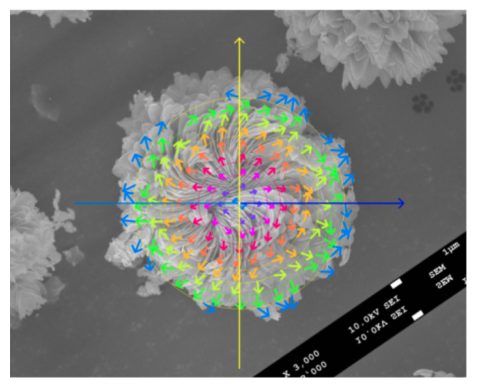

In [3]:
from PIL import Image

import matplotlib.pyplot as plt

# Load image.png
img = Image.open('image.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Center at: (336.00, 284.50)


/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_25268/1263897385.py:33: RuntimeWarning: overflow encountered in scalar subtract
  denom = (y0 - 2*y1 + y2)
/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_25268/1263897385.py:36: RuntimeWarning: overflow encountered in scalar subtract
  return float(peak + 0.5 * (y0 - y2) / denom)


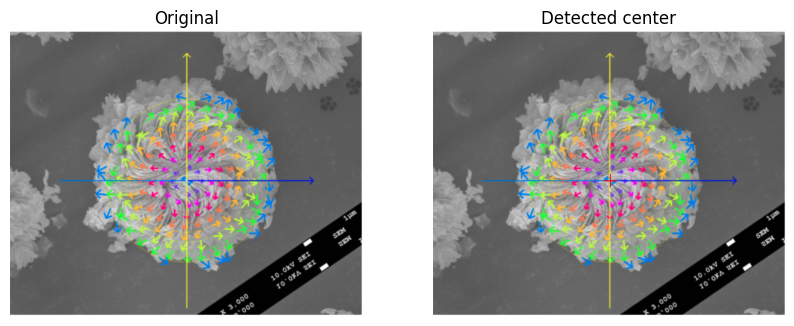

In [17]:
import numpy as np
import cv2
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def find_crosshair_center_color(pil_img,
                                yellow_range=((15, 80, 120), (45, 255, 255)),
                                blue_range=((90, 50, 70), (135, 255, 255)),
                                refine=True):
    """
    Find intersection of yellow (vertical) and blue (horizontal) axes.
    Returns (x_center, y_center), plus masks for debug.
    """
    bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    y_low, y_high = yellow_range
    b_low, b_high = blue_range
    mask_y = cv2.inRange(hsv, np.array(y_low), np.array(y_high))
    mask_b = cv2.inRange(hsv, np.array(b_low), np.array(b_high))

    # Projections
    col_y = mask_y.sum(axis=0)  # vertical line -> peak column
    row_b = mask_b.sum(axis=1)  # horizontal line -> peak row
    x_peak = int(np.argmax(col_y))
    y_peak = int(np.argmax(row_b))

    # Optional subpixel refinement via quadratic fit
    def subpixel_peak(proj, peak):
        if not refine or peak <= 0 or peak >= len(proj)-1:
            return float(peak)
        y0, y1, y2 = proj[peak-1], proj[peak], proj[peak+1]
        denom = (y0 - 2*y1 + y2)
        if denom == 0:
            return float(peak)
        return float(peak + 0.5 * (y0 - y2) / denom)

    x_center = subpixel_peak(col_y, x_peak)
    y_center = subpixel_peak(row_b, y_peak)
    return x_center, y_center, mask_y, mask_b

# Use it
img = Image.open("image.png")
xc, yc, mask_y, mask_b = find_crosshair_center_color(img)
print(f"Center at: ({xc:.2f}, {yc:.2f})")

# Visualize
vis = img.copy()
draw = ImageDraw.Draw(vis)
draw.line((xc-12, yc, xc+12, yc), fill='red', width=2)
draw.line((xc, yc-12, xc, yc+12), fill='red', width=2)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img); plt.axis('off'); plt.title('Original')
plt.subplot(1,2,2); plt.imshow(vis); plt.axis('off'); plt.title('Detected center')
plt.show()

In [23]:
import ast
# !pip install pandas
import pandas as pd
from pathlib import Path
import numpy as np

# from os import Path

# --- Load data ---
csv_path = Path.cwd().parent / "vf_exports" / "Front_EE-1_1_3000x_rings_coords.csv"
df = pd.read_csv(csv_path)
print(type(df['Coordinate'][0]))

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]
        
angles_deg = df['Angle (α′)'].values 

# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta)


# For these angles and coordinates, plot a vector field
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]

<class 'str'>


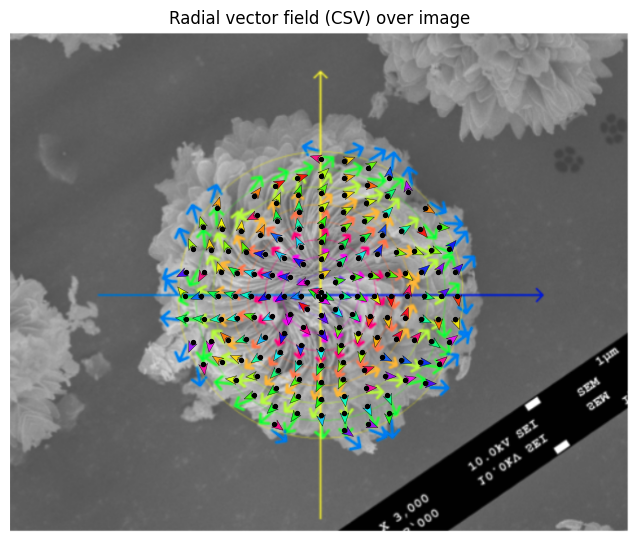

In [24]:
# # !pip install pandas
# import pandas as pd
# from pathlib import Path

# # from os import Path

# # --- Load data ---
# csv_path = Path.cwd().parent / "vf_exports" / "Front_EE-1_1_3000x_rings_coords.csv"
# df = pd.read_csv(csv_path)
# print(type(df['Coordinate']))
# # Parse "(x, y)" strings to floats
# def parse_coord(s):
#     s = s.strip("()")
#     print(s)
#     x_str, y_str = s.split(",")
#     return float(x_str), float(y_str)

# coords = df["Coordinate"].apply(parse_coord)
X_rel = np.array([c[0] for c in coordinates])
Y_rel = np.array([c[1] for c in coordinates])
# angles_deg = df["Angle (α′)"].to_numpy()

# --- Map to pixel space (center = xc, yc) ---
pixels_per_unit = 1.0  # adjust if vectors are too tight/loose
x_pix = xc + pixels_per_unit * X_rel * 0.5
y_pix = yc - pixels_per_unit * Y_rel * 0.5# invert Y for image coords

# --- Vector components (angles given in degrees) ---
phi_rad = np.deg2rad(phi)

arrow_len = 12  # pixels; bump up/down to taste
u = arrow_len * np.cos(phi_rad)
v = -arrow_len * np.sin(phi_rad)  # minus to match image Y direction

# --- Plot on top of the image ---
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.quiver(
    x_pix, y_pix, u, v, angles_deg,
    angles='xy', scale_units='xy', scale=1,
    cmap='hsv', width=0.01, headwidth=8, headlength=10, headaxislength=7,
    alpha=0.9, edgecolor='k', linewidth=0.3
)
plt.scatter(x_pix, y_pix, c='k', s=8, zorder=3)
plt.axis('off')
plt.title("Radial vector field (CSV) over image")
plt.show()